##  EMI- PREDICT PROJECT
## STEP-1: DATA EXPLORATION 

In [7]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("data/emi_prediction_dataset.csv", low_memory=False)
print(df.shape)

(404800, 27)


In [9]:
df.dtypes


age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object

This data set contains 404800 data's with 27 columns.

In [10]:
#seperate numerical and categorical_cols
numerical_cols= df. select_dtypes(include=['int64','float64']). columns.tolist()
categorical_cols = df. select_dtypes(include=['object']).columns. tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns (15): ['years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']
Categorical columns (12): ['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']


In [11]:
#count missing values per column
missing_values = df. isnull().sum()
print(missing_values)

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64


In [12]:
missing_pct=(df.isnull().sum()/len(df))*100
print(missing_pct)

age                       0.000000
gender                    0.000000
marital_status            0.000000
education                 0.593874
monthly_salary            0.000000
employment_type           0.000000
years_of_employment       0.000000
company_type              0.000000
house_type                0.000000
monthly_rent              0.599308
family_size               0.000000
dependents                0.000000
school_fees               0.000000
college_fees              0.000000
travel_expenses           0.000000
groceries_utilities       0.000000
other_monthly_expenses    0.000000
existing_loans            0.000000
current_emi_amount        0.000000
credit_score              0.597826
bank_balance              0.599308
emergency_fund            0.580781
emi_scenario              0.000000
requested_amount          0.000000
requested_tenure          0.000000
emi_eligibility           0.000000
max_monthly_emi           0.000000
dtype: float64


In [13]:
missing_df= pd.DataFrame({
    'Missing Values':missing_values,
    'Missing Percentage': missing_pct
})
print(missing_df[missing_df['Missing Values']>0].sort_values('Missing Percentage', ascending=False))

                Missing Values  Missing Percentage
monthly_rent              2426            0.599308
bank_balance              2426            0.599308
credit_score              2420            0.597826
education                 2404            0.593874
emergency_fund            2351            0.580781


In [14]:
#check duplicated rows
print(f"Total duplicate rows:{df.duplicated().sum()}")

Total duplicate rows:0


In [15]:
df.describe()

,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


In [16]:
#check unique values for categorical columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(f"Values:{df[col].unique()}")
    print("=="*50)

age: 31 unique values
Values:['38' '58' '48' '32' '27' '47' '58.0' '37' '32.0' '27.0' '38.0' '31' '59'
 '49' '33' '26' '48.0' '39' '57' '28' '59.0' '37.0' '49.0' '58.0.0' '39.0'
 '26.0' '28.0' '38.0.0' '33.0' '32.0.0' '31.0']
gender: 8 unique values
Values:['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
marital_status: 2 unique values
Values:['Married' 'Single']
education: 4 unique values
Values:['Professional' 'Graduate' 'High School' 'Post Graduate' nan]
monthly_salary: 13662 unique values
Values:['82600.0' '21500.0' '86100.0' ... '56779.0' '56280.0' '55905.0']
employment_type: 3 unique values
Values:['Private' 'Government' 'Self-employed']
company_type: 5 unique values
Values:['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']
house_type: 3 unique values
Values:['Rented' 'Family' 'Own']
existing_loans: 2 unique values
Values:['Yes' 'No']
bank_balance: 12261 unique values
Values:['303200.0' '92500.0' '672100.0' ... '1026700.0' '302100.0.0' '141400.0.0']
emi_scenario: 5 uniq

In [17]:
#check target variable distribution and classification
print(df['emi_eligibility'].value_counts())
print("\n")
print(df['emi_eligibility'].value_counts(normalize=True)*100)

emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64


emi_eligibility
Not_Eligible    77.289526
Eligible        18.390316
High_Risk        4.320158
Name: proportion, dtype: float64


In [18]:
#check target variable distribution- regression
print(df['max_monthly_emi'].describe())

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


In [19]:
#correlation
print(df[numerical_cols].corr()['max_monthly_emi'].sort_values(ascending=False))


max_monthly_emi           1.000000
groceries_utilities       0.484695
travel_expenses           0.440948
emergency_fund            0.415231
other_monthly_expenses    0.382055
credit_score              0.229441
years_of_employment       0.028887
requested_tenure          0.001006
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.170097
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
Name: max_monthly_emi, dtype: float64


In [20]:
#check cardinality
for col in categorical_cols:
    print(f"{col}:{df[col]. nunique()} unique values")

age:31 unique values
gender:8 unique values
marital_status:2 unique values
education:4 unique values
monthly_salary:13662 unique values
employment_type:3 unique values
company_type:5 unique values
house_type:3 unique values
existing_loans:2 unique values
bank_balance:12261 unique values
emi_scenario:5 unique values
emi_eligibility:3 unique values


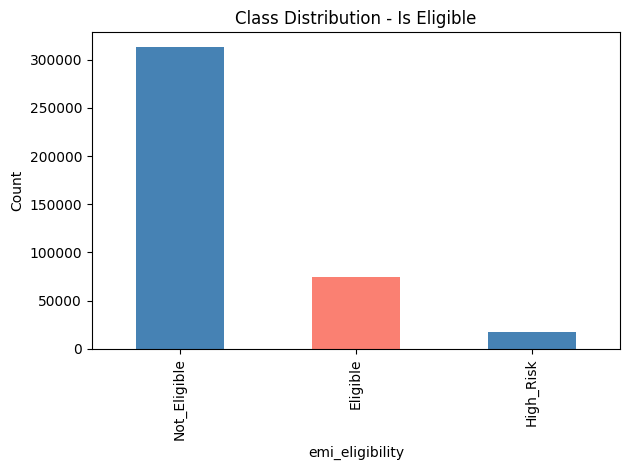

In [21]:
#check class imbalance for classification target
import matplotlib.pyplot as plt
df['emi_eligibility'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution - Is Eligible')
plt.xlabel('emi_eligibility')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

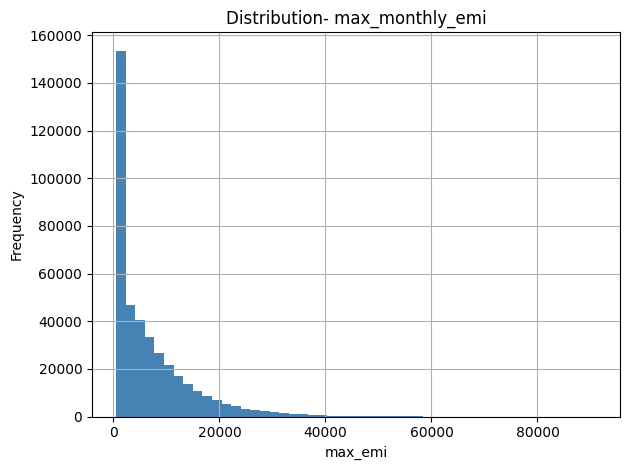

In [22]:
#check distribution of regression target
df['max_monthly_emi'].hist(bins=50, color='steelblue')
plt.title('Distribution- max_monthly_emi')
plt.xlabel('max_emi')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [23]:
#check skewness - numerical_cols
print(df[numerical_cols].skew().sort_values(ascending=False))


years_of_employment       2.147970
max_monthly_emi           1.974159
emergency_fund            1.790000
current_emi_amount        1.777650
monthly_rent              1.612384
college_fees              1.539982
other_monthly_expenses    1.404994
requested_amount          1.386145
travel_expenses           1.355937
groceries_utilities       1.228968
requested_tenure          0.918680
school_fees               0.584345
family_size               0.022211
dependents                0.022211
credit_score             -1.094064
dtype: float64


In [24]:
#final summery of data exploration
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Numerical Columns : {len(numerical_cols)}")
print(f"Categorical Columns : {len(categorical_cols)}")
print(f"Total Missing Values : {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows : {df.duplicated().sum()}")
print(f"Class Balance (is_eligible) : \n {df['emi_eligibility'].value_counts()}")



Total Rows: 404800
Total Columns: 27
Numerical Columns : 15
Categorical Columns : 12
Total Missing Values : 12027
Total Duplicate Rows : 0
Class Balance (is_eligible) : 
 emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64


## STEP-2: DATA CLEANING

In [25]:
#check missing values
missing_df = pd.DataFrame ({
    'Missing count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) *100
})
print(missing_df[missing_df['Missing count']>0].sort_values('Missing Percentage',ascending=False))

                Missing count  Missing Percentage
monthly_rent             2426            0.599308
bank_balance             2426            0.599308
credit_score             2420            0.597826
education                2404            0.593874
emergency_fund           2351            0.580781


In [26]:
#check skewness of  columns with missing values
cols_to_check= ['monthly_rent','bank_balance','credit_score','emergency_fund']
for col in cols_to_check:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(df[cols_to_check].skew())

monthly_rent      1.612384
bank_balance      1.414282
credit_score     -1.094064
emergency_fund    1.790000
dtype: float64


In [27]:
df.iloc[:, 0].unique()

array(['38', '58', '48', '32', '27', '47', '58.0', '37', '32.0', '27.0',
       '38.0', '31', '59', '49', '33', '26', '48.0', '39', '57', '28',
       '59.0', '37.0', '49.0', '58.0.0', '39.0', '26.0', '28.0', '38.0.0',
       '33.0', '32.0.0', '31.0'], dtype=object)

In [28]:
df['age'] = df['age'].str.replace('.0.0', '', regex=False)
df['age'] = df['age'].str.replace('.0', '', regex=False)

In [29]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [30]:
df['age'].isnull().sum()

np.int64(0)

In [31]:
df.iloc[:, 1].unique()

array(['Female', 'Male', 'female', 'male', 'M', 'MALE', 'F', 'FEMALE'],
      dtype=object)

In [32]:
df['gender'] = df['gender'].str.lower()

In [33]:
df['gender'] = df['gender'].replace({
    'm': 'male',
    'f': 'female'
})

In [34]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [35]:
df.iloc[:,2].unique()

array(['Married', 'Single'], dtype=object)

In [36]:
df['marital_status'] = df['marital_status'].str.lower()

In [37]:
df.iloc[:, 3].unique()

array(['Professional', 'Graduate', 'High School', 'Post Graduate', nan],
      dtype=object)

In [38]:
df['education'] = df['education'].str.lower().str.strip()

In [39]:
df['education'] = df['education'].replace({
    'post graduate': 'post_graduate',
    'high school': 'high_school'
})

In [40]:
# Before you fill them
print(f"Total missing values: {df['education'].isna().sum()}")

Total missing values: 2404


In [41]:

print("Rows where education_level is currently missing (NaN):")
print(df[df['education'].isna()].head())


Rows where education_level is currently missing (NaN):
     age  gender marital_status education monthly_salary employment_type  \
111   38  female        married       NaN        46100.0         Private   
426   38  female        married       NaN        15000.0      Government   
455   48    male        married       NaN        53200.0         Private   
593   48  female        married       NaN        42300.0   Self-employed   
773   32  female         single       NaN        46100.0         Private   

     years_of_employment  company_type house_type  monthly_rent  ...  \
111                  3.4           MNC        Own           0.0  ...   
426                  4.2           MNC     Family           0.0  ...   
455                  3.4         Small     Rented       15800.0  ...   
593                 15.6  Large Indian     Family           0.0  ...   
773                 10.0  Large Indian     Rented       11400.0  ...   

     existing_loans  current_emi_amount  credit_score  

In [42]:
df['education'].fillna('unknown', inplace=True)
df['education'].unique()

array(['professional', 'graduate', 'high_school', 'post_graduate',
       'unknown'], dtype=object)

In [43]:
df['employment_type'].unique()

array(['Private', 'Government', 'Self-employed'], dtype=object)

In [44]:
df['employment_type'] = df['employment_type'].str.lower().str.strip()

In [45]:
df['employment_type'] = df['employment_type'].replace({
    'self-employed': 'self_employed'
})

In [46]:
df['company_type'].unique()

array(['Mid-size', 'MNC', 'Startup', 'Large Indian', 'Small'],
      dtype=object)

In [47]:
df['company_type'] = df['company_type'].str.lower().str.strip()

In [48]:
df['company_type'] = df['company_type'].replace({
    'mid-size': 'mid_size',
    'large indian': 'large_indian'
})

In [49]:
df['house_type'].unique()

array(['Rented', 'Family', 'Own'], dtype=object)

In [50]:
df['house_type'] = df['house_type'].str.lower().str.strip()

In [51]:
df['emi_scenario'].unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [52]:
df['emi_scenario'] = df['emi_scenario'].str.lower().str.strip()

In [53]:
df['emi_scenario'] = df['emi_scenario'].str.replace(' ', '_')
df['emi_scenario'] = df['emi_scenario'].str.replace('-', '_')

In [54]:
df['emi_eligibility'].unique()

array(['Not_Eligible', 'Eligible', 'High_Risk'], dtype=object)

In [55]:
df['emi_eligibility'] = df['emi_eligibility'].str.lower().str.strip()

In [56]:
df['emi_eligibility'] = df['emi_eligibility'].replace({
    'not_eligible': 'not_eligible',
    'high_risk': 'high_risk',
    'eligible': 'eligible'
})

In [57]:
df['monthly_salary'].unique()[:20]


array(['82600.0', '21500.0', '86100.0', '66800.0', '57300.0', '38800.0',
       '27100.0', '392044.0', '47700.0', '129200.0', '58600.0', '47000.0',
       '11837.0', '53900.0', '110800.0', '64000.0', '46600.0', '77400.0',
       '40700.0', '47500.0'], dtype=object)

In [58]:
df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')

deal with monthly salaries and age

In [59]:
df['existing_loans'].unique()[:20]

array(['Yes', 'No'], dtype=object)

In [60]:
df['existing_loans'] = df['existing_loans'].str.lower().str.strip()

In [61]:
# 1. Strip whitespace and convert to numeric
df['bank_balance'] = pd.to_numeric(df['bank_balance'].astype(str).str.strip(), errors='coerce')

In [62]:
df['years_of_employment'].head(10)

0     0.9
1     7.0
2     5.8
3     2.2
4     3.4
5     5.0
6    36.0
7    12.9
8    36.0
9     1.9
Name: years_of_employment, dtype: float64

In [63]:
#seperate numerical and categorical_cols
numerical_cols= df. select_dtypes(include=['int64','float64']). columns.tolist()
categorical_cols = df. select_dtypes(include=['object']).columns. tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns (18): ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']
Categorical columns (9): ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'emi_eligibility']


In [64]:
#check unique values for categorical columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(f"Values:{df[col].unique()}")
    print("=="*50)

gender: 2 unique values
Values:['female' 'male']
marital_status: 2 unique values
Values:['married' 'single']
education: 5 unique values
Values:['professional' 'graduate' 'high_school' 'post_graduate' 'unknown']
employment_type: 3 unique values
Values:['private' 'government' 'self_employed']
company_type: 5 unique values
Values:['mid_size' 'mnc' 'startup' 'large_indian' 'small']
house_type: 3 unique values
Values:['rented' 'family' 'own']
existing_loans: 2 unique values
Values:['yes' 'no']
emi_scenario: 5 unique values
Values:['personal_loan_emi' 'e_commerce_shopping_emi' 'education_emi'
 'vehicle_emi' 'home_appliances_emi']
emi_eligibility: 3 unique values
Values:['not_eligible' 'eligible' 'high_risk']


In [65]:
#check skewness of  columns with missing values

for col in cols_to_check:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(df[cols_to_check].skew())

monthly_rent      1.612384
bank_balance      1.414282
credit_score     -1.094064
emergency_fund    1.790000
dtype: float64


In [66]:
#check target variable distribution- regression
print(df['max_monthly_emi'].describe())

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


In [67]:
#correlation
print(df[numerical_cols].corr()['max_monthly_emi'].sort_values(ascending=False))


max_monthly_emi           1.000000
groceries_utilities       0.484695
bank_balance              0.458666
travel_expenses           0.440948
emergency_fund            0.415231
other_monthly_expenses    0.382055
monthly_salary            0.379210
credit_score              0.229441
years_of_employment       0.028887
requested_tenure          0.001006
age                      -0.000855
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.170097
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
Name: max_monthly_emi, dtype: float64


In [68]:
#check cardinality
for col in categorical_cols:
    print(f"{col}:{df[col]. nunique()} unique values")

gender:2 unique values
marital_status:2 unique values
education:5 unique values
employment_type:3 unique values
company_type:5 unique values
house_type:3 unique values
existing_loans:2 unique values
emi_scenario:5 unique values
emi_eligibility:3 unique values


In [69]:
#check skewness - numerical_cols
print(df[numerical_cols].skew().sort_values(ascending=False))


monthly_salary            4.833037
years_of_employment       2.147970
max_monthly_emi           1.974159
emergency_fund            1.790000
current_emi_amount        1.777650
monthly_rent              1.612384
college_fees              1.539982
bank_balance              1.414282
other_monthly_expenses    1.404994
requested_amount          1.386145
travel_expenses           1.355937
groceries_utilities       1.228968
requested_tenure          0.918680
age                       0.652411
school_fees               0.584345
family_size               0.022211
dependents                0.022211
credit_score             -1.094064
dtype: float64


In [70]:
#partial data cleaning summery
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Numerical Columns : {len(numerical_cols)}")
print(f"Categorical Columns : {len(categorical_cols)}")
print(f"Total Missing Values : {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows : {df.duplicated().sum()}")
print(f"Class Balance (is_eligible) : \n {df['emi_eligibility'].value_counts()}")



Total Rows: 404800
Total Columns: 27
Numerical Columns : 18
Categorical Columns : 9
Total Missing Values : 13582


Total Duplicate Rows : 0
Class Balance (is_eligible) : 
 emi_eligibility
not_eligible    312868
eligible         74444
high_risk        17488
Name: count, dtype: int64


In [71]:
#check outliers using IQR for numerical columns with missing values
cols_to_check= ['monthly_rent','bank_balance','credit_score','emergency_fund']
for col in cols_to_check:
    Q1=df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR= Q3-Q1
    lower = Q1- 1.5*IQR
    upper=Q3 +1.5*IQR
    outliers = df[(df[col]<lower)| (df[col]>upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(df)*100, 2)}%)")


monthly_rent — Outliers: 12720 (3.14%)
bank_balance — Outliers: 12950 (3.2%)
credit_score — Outliers: 5840 (1.44%)
emergency_fund — Outliers: 17542 (4.33%)


In [72]:
df['credit_score'].describe()

count    402380.000000
mean        700.856223
std          88.435548
min           0.000000
25%         654.000000
50%         701.000000
75%         748.000000
max        1200.000000
Name: credit_score, dtype: float64

In [73]:

print("Before correction:")
print(f"Min: {df['credit_score'].min()}")
print(f"Max: {df['credit_score'].max()}")
print(f"Values < 300: {(df['credit_score'] < 300).sum()}")
print(f"Values > 900: {(df['credit_score'] > 850).sum()}")

df.loc[(df['credit_score'] < 300) | (df['credit_score'] > 8500), 'credit_score'] = np.nan

print("\nAfter correction:")
print(f"New missing values: {df['credit_score'].isna().sum()}")
print(f"Min: {df['credit_score'].min()}")
print(f"Max: {df['credit_score'].max()}")
print(df['credit_score'].describe())

Before correction:
Min: 0.0
Max: 1200.0
Values < 300: 1566
Values > 900: 3210

After correction:
New missing values: 3986
Min: 407.0
Max: 1200.0
count    400814.000000
mean        703.594503
std          76.972458
min         407.000000
25%         654.000000
50%         701.000000
75%         748.000000
max        1200.000000
Name: credit_score, dtype: float64


In [74]:
df.loc[df['house_type'].isin(['own', 'family']) & df['monthly_rent'].isna(), 'monthly_rent'] = 0


In [75]:

missing_rent_df = df[df['monthly_rent'].isnull()]
print(len(missing_rent_df))
print(missing_rent_df.head())

939
      age  gender marital_status      education  monthly_salary  \
183    48    male        married  post_graduate        111000.0   
903    38  female        married       graduate         39200.0   
1699   27    male         single   professional         86600.0   
2061   38  female        married       graduate         66600.0   
3034   27    male        married       graduate         20000.0   

     employment_type  years_of_employment  company_type house_type  \
183          private                  1.7  large_indian     rented   
903          private                  1.4      mid_size     rented   
1699         private                  0.5           mnc     rented   
2061         private                  1.8       startup     rented   
3034         private                  2.5      mid_size     rented   

      monthly_rent  ...  existing_loans  current_emi_amount  credit_score  \
183            NaN  ...              no                 0.0         803.0   
903            NaN

In [76]:

df['monthly_rent'] = df.groupby(
    ['house_type', 'family_size']
)['monthly_rent'].transform(lambda x: x.fillna(x.median()))

df['monthly_rent'] = df['monthly_rent'].fillna(df['monthly_rent'].median())

print(f"Missing monthly_rent: {df['monthly_rent'].isna().sum()}")

Missing monthly_rent: 0


In [77]:
#Fill nans using similar groups
df['bank_balance'] = df['bank_balance'].fillna(
    df.groupby(['education', 'employment_type'])['bank_balance'].transform('median')
)

#Fill any remaining nans with global median
df['bank_balance'] = df['bank_balance'].fillna(df['bank_balance'].median())

#Calculate the IQR Fence for the entire bank_balance column
Q1 = df['bank_balance'].quantile(0.25)
Q3 = df['bank_balance'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# 4. Apply the Cap
df['bank_balance'] = df['bank_balance'].clip(lower=0, upper=upper_fence)

print(f"Bank Balance processed for 4L rows.")
print(f"Imputation complete. Column capped at {upper_fence}.")

Bank Balance processed for 4L rows.
Imputation complete. Column capped at 665050.0.


In [78]:

# Create a summary table
outlier_audit = pd.DataFrame()

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    
    outlier_audit.loc[col, 'Min'] = df[col].min()
    outlier_audit.loc[col, 'Max'] = df[col].max()
    outlier_audit.loc[col, 'Upper_Fence'] = upper_fence
    # Any value > Upper_Fence is technically an outlier
    outlier_audit.loc[col, 'Outliers_Remaining'] = (df[col] > upper_fence).sum()

print("--- Final Numerical Audit ---")
print(outlier_audit)

--- Final Numerical Audit ---
                            Min        Max  Upper_Fence  Outliers_Remaining
age                        26.0       59.0         72.0                 0.0
monthly_salary           3967.0   499970.0     129400.0             12070.0
years_of_employment         0.5       36.0         16.2             22891.0
monthly_rent                0.0    80000.0      26750.0             12365.0
family_size                 1.0        5.0          7.0                 0.0
dependents                  0.0        4.0          6.0                 0.0
school_fees                 0.0    15000.0      22500.0                 0.0
college_fees                0.0    25000.0      16250.0             48000.0
travel_expenses           600.0    30300.0      13700.0             12465.0
groceries_utilities      1800.0    71200.0      29450.0             11774.0
other_monthly_expenses    600.0    42900.0      17550.0             13518.0
current_emi_amount          0.0    56300.0      20000.0   

In [79]:

df['monthly_salary'] = df['monthly_salary'].clip(lower=15000, upper=200000)
print("Salary Min/Max:", df['monthly_salary'].min(), "-", df['monthly_salary'].max())


Salary Min/Max: 15000.0 - 200000.0


In [91]:

remaining_cols = [
    'college_fees', 'travel_expenses', 'groceries_utilities', 
    'other_monthly_expenses', 'current_emi_amount', 
    'requested_amount', 'requested_tenure', 'max_monthly_emi'
]

skew_audit = pd.DataFrame()

for col in remaining_cols:
    skew_audit.loc[col, 'Skewness'] = df[col].skew()
    skew_audit.loc[col, '99th_Percentile'] = df[col].quantile(0.99)
    skew_audit.loc[col, 'Max_Value'] = df[col].max()

print(skew_audit.sort_values(by='Skewness', ascending=False))

                        Skewness  99th_Percentile  Max_Value
max_monthly_emi         1.892463          34782.0    50000.0
college_fees            1.539980          24300.0    25000.0
requested_amount        1.386177        1430000.0  1500000.0
current_emi_amount      1.234543          20000.0    20000.0
requested_tenure        0.918646             81.0       84.0
other_monthly_expenses  0.896225          17550.0    17550.0
travel_expenses         0.880164          13700.0    13700.0
groceries_utilities     0.813917          29450.0    29450.0


In [81]:
# Aligning the target variable with project requirement
df['max_monthly_emi'] = df['max_monthly_emi'].clip(lower=500, upper=50000)

print(f"Min: {df['max_monthly_emi'].min()} | Max: {df['max_monthly_emi'].max()}")

Min: 500.0 | Max: 50000.0


In [82]:
# 1. Calculate IQR for current_emi_amount
Q1_ce = df['current_emi_amount'].quantile(0.25)
Q3_ce = df['current_emi_amount'].quantile(0.75)
IQR_ce = Q3_ce - Q1_ce

# Upper fence is 20,000 based on your earlier audit
upper_fence_ce = Q3_ce + 1.5 * IQR_ce

# 2. Apply the cap
df['current_emi_amount'] = df['current_emi_amount'].clip(upper=upper_fence_ce)

print(f"current_emi_amount (Feature) capped at: {upper_fence_ce}")

current_emi_amount (Feature) capped at: 20000.0


In [83]:

df['requested_amount'] = df['requested_amount'].clip(upper=1500000)

print(f"Requested Amount capped as per project instruction: {df['requested_amount'].max()}")

Requested Amount capped as per project instruction: 1500000.0


In [84]:
# List of lifestyle expenses to cap using IQR
expense_cols = ['travel_expenses', 'groceries_utilities', 'other_monthly_expenses']

for col in expense_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    
    # Capping the extreme lifestyle spenders
    df[col] = df[col].clip(upper=upper_fence)
    print(f"{col} capped at: {upper_fence}")

travel_expenses capped at: 13700.0
groceries_utilities capped at: 29450.0
other_monthly_expenses capped at: 17550.0


In [85]:
# Aligning tenure with the absolute max and min from your project specs
df['requested_tenure'] = df['requested_tenure'].clip(lower=3, upper=84)

print(f"Requested Tenure aligned. Min: {df['requested_tenure'].min()}, Max: {df['requested_tenure'].max()}")

Requested Tenure aligned. Min: 3, Max: 84


In [86]:

impossible_workers = df[df['age'] - df['years_of_employment'] < 15]

impossible_tenure = df[df['age'] + (df['requested_tenure'] / 12) > 65]

print(f"Rows with impossible Age/Work logic: {len(impossible_workers)}")
print(f"Rows where loan outlasts retirement (age 65): {len(impossible_tenure)}")

Rows with impossible Age/Work logic: 0
Rows where loan outlasts retirement (age 65): 5


In [87]:
# Dropping the 5 rows where the loan outlasts retirement age (65)
df = df[df['age'] + (df['requested_tenure'] / 12) <= 65]

print(f"Final Row Count: {len(df)}")

Final Row Count: 404795


In [88]:
from sklearn.impute import KNNImputer


cols_for_imputation = ['bank_balance', 'emergency_fund', 'monthly_salary', 
                       'groceries_utilities', 'credit_score']

imputer = KNNImputer(n_neighbors=5)
df[cols_for_imputation] = imputer.fit_transform(df[cols_for_imputation])

df['credit_score'] = df['credit_score'].round().clip(300, 850)

print(f"Missing credit scores: {df['credit_score'].isna().sum()}")
print(df['credit_score'].describe())

Missing credit scores: 0
count    404795.000000
mean        701.594713
std          68.645729
min         407.000000
25%         655.000000
50%         701.000000
75%         748.000000
max         850.000000
Name: credit_score, dtype: float64


In [90]:
# Check skewness and outliers for the newly suspicious columns
final_outlier_check = ['monthly_rent', 'bank_balance', 'emergency_fund']

for col in final_outlier_check:
    print(f"{col} Skew: {df[col].skew():.2f}")

monthly_rent Skew: 1.61
bank_balance Skew: 0.93
emergency_fund Skew: 1.79


In [92]:
cols_to_cap = ['monthly_rent', 'bank_balance', 'emergency_fund']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    
    # Clip the data
    df[col] = df[col].clip(upper=upper_fence)
    print(f"{col} - Upper Fence: {upper_fence:.2f}")

df['emergency_fund'] = df[['emergency_fund', 'bank_balance']].min(axis=1)

print("\nOutliers capped and logic synchronized.")

monthly_rent - Upper Fence: 26750.00
bank_balance - Upper Fence: 665050.00
emergency_fund - Upper Fence: 268900.00

Outliers capped and logic synchronized.


In [93]:
final_check = pd.DataFrame()
for col in numerical_cols:
    final_check.loc[col, 'Min'] = df[col].min()
    final_check.loc[col, 'Max'] = df[col].max()

print(final_check)

                            Min        Max
age                        26.0       59.0
monthly_salary          15000.0   200000.0
years_of_employment         0.5       36.0
monthly_rent                0.0    26750.0
family_size                 1.0        5.0
dependents                  0.0        4.0
school_fees                 0.0    15000.0
college_fees                0.0    25000.0
travel_expenses           600.0    13700.0
groceries_utilities      1800.0    29450.0
other_monthly_expenses    600.0    17550.0
current_emi_amount          0.0    20000.0
credit_score              407.0      850.0
bank_balance             6100.0   665050.0
emergency_fund           1400.0   268900.0
requested_amount        10000.0  1500000.0
requested_tenure            3.0       84.0
max_monthly_emi           500.0    50000.0


In [94]:
for col in categorical_cols:
    if col in df.columns:
        print(f"--- {col.upper()} ---")
        print(df[col].unique())

--- GENDER ---
['female' 'male']
--- MARITAL_STATUS ---
['married' 'single']
--- EDUCATION ---
['professional' 'graduate' 'high_school' 'post_graduate' 'unknown']
--- EMPLOYMENT_TYPE ---
['private' 'government' 'self_employed']
--- COMPANY_TYPE ---
['mid_size' 'mnc' 'startup' 'large_indian' 'small']
--- HOUSE_TYPE ---
['rented' 'family' 'own']
--- EXISTING_LOANS ---
['yes' 'no']
--- EMI_SCENARIO ---
['personal_loan_emi' 'e_commerce_shopping_emi' 'education_emi'
 'vehicle_emi' 'home_appliances_emi']
--- EMI_ELIGIBILITY ---
['not_eligible' 'eligible' 'high_risk']


In [95]:

mode_education = df[df['education'] != 'unknown']['education'].mode()[0]
df['education'] = df['education'].replace('unknown', mode_education)

print("Final Education Categories:", df['education'].unique())


Final Education Categories: ['professional' 'graduate' 'high_school' 'post_graduate']


In [97]:

df.loc[df['house_type'] != 'rented', 'monthly_rent'] = 0

non_renter_rent = df[df['house_type'] != 'rented']['monthly_rent'].sum()
print(f"Total rent for non-renters (should be 0): {non_renter_rent}")

Total rent for non-renters (should be 0): 0.0


In [98]:

df.loc[df['dependents'] == 0, ['school_fees', 'college_fees']] = 0

In [99]:

import numpy as np

# 1. THE NUMERICAL AUDIT

requirements = {
    'age': (25, 60),
    'monthly_salary': (15000, 200000),
    'credit_score': (300, 850),
    'requested_amount': (10000, 1500000),
    'requested_tenure': (3, 84),
    'max_monthly_emi': (0, 50000)
}

print("--- Numerical Range Check ---")
for col, (min_val, max_val) in requirements.items():
    actual_min = df[col].min()
    actual_max = df[col].max()
    status = "✅ PASS" if (actual_min >= min_val and actual_max <= max_val) else "❌ FAIL"
    print(f"{col:20}: Req({min_val}-{max_val}) | Actual({actual_min}-{actual_max}) -> {status}")

# 2. THE CATEGORICAL AUDIT

required_edu = {'high_school', 'graduate', 'post_graduate', 'professional'}
actual_edu = set(df['education'].unique())
edu_status = "✅ PASS" if actual_edu.issubset(required_edu) else f"❌ FAIL (Found: {actual_edu})"

print(f"\n--- Categorical Requirements ---")
print(f"Education Categories: {edu_status}")

# 3. THE LOGIC AUDIT

rent_logic_errors = len(df[(df['house_type'] != 'rented') & (df['monthly_rent'] > 0)])

fees_logic_errors = len(df[(df['dependents'] == 0) & ((df['school_fees'] > 0) | (df['college_fees'] > 0))])

print(f"Rent Logic Errors    : {rent_logic_errors} (Expected: 0)")
print(f"Fee Logic Errors     : {fees_logic_errors} (Expected: 0)")

# 4. FINAL NULL CHECK
total_nans = df.isna().sum().sum()
print(f"\nTotal Missing Values : {total_nans} (Expected: 0)")

--- Numerical Range Check ---
age                 : Req(25-60) | Actual(26-59) -> ✅ PASS
monthly_salary      : Req(15000-200000) | Actual(15000.0-200000.0) -> ✅ PASS
credit_score        : Req(300-850) | Actual(407.0-850.0) -> ✅ PASS
requested_amount    : Req(10000-1500000) | Actual(10000.0-1500000.0) -> ✅ PASS
requested_tenure    : Req(3-84) | Actual(3-84) -> ✅ PASS
max_monthly_emi     : Req(0-50000) | Actual(500.0-50000.0) -> ✅ PASS

--- Categorical Requirements ---
Education Categories: ✅ PASS
Rent Logic Errors    : 0 (Expected: 0)
Fee Logic Errors     : 0 (Expected: 0)

Total Missing Values : 0 (Expected: 0)


In [101]:
# Quick Skewness Audit for the new notebook
skew_df = df.skew(numeric_only=True).sort_values(ascending=False).reset_index()
skew_df.columns = ['Feature', 'Skewness']

# Highlight features that are still highly skewed (> 1)
high_skew = skew_df[skew_df['Skewness'].abs() > 1]
print("Features with remaining significant skew:")
print(high_skew)

Features with remaining significant skew:
               Feature  Skewness
0  years_of_employment  2.147975
1      max_monthly_emi  1.892463
2         college_fees  1.539980
3       monthly_salary  1.461384
4     requested_amount  1.386177
5         monthly_rent  1.256236
6   current_emi_amount  1.234543


In [ ]:
df.to_csv("data/cleaned_data.csv", index=False)